# Regression residual diagnostics
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/rbig/blob/main/docs/notebooks/25_residual_diagnostics.ipynb)

`ResidualDiagnostics` wraps any regressor and turns "eyeball the
residual plot" into three numbers in nats:

- **Non-Gaussian residuals** `J(ε)` — negentropy,
- **Missed structure** `I(ε; X_j)` per feature — the top offender names
  the term to add,
- **Heteroskedasticity** `I(ε²; X)`.

It is a drop-in meta-estimator: `predict`/`score` delegate to the
wrapped model.

> **Colab / fresh environment?** Run the cell below to install `rbig`.
> Skip if already installed.

In [ ]:
!pip install "rbig[all] @ git+https://github.com/jejjohnson/rbig.git" -q

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

from rbig import ResidualDiagnostics

plt.style.use("seaborn-v0_8-paper")

/home/user/rbig/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data: a missed quadratic term

The target depends on `x0` **quadratically**, but we first fit a plain
linear model — so the misspecification should show up as structure in
`I(ε; x0)`.

In [3]:
rng = np.random.default_rng(0)
n = 1200
X = rng.standard_normal((n, 3))
y = X[:, 0] ** 2 + X[:, 1] + 0.3 * rng.standard_normal(n)

lin = ResidualDiagnostics(LinearRegression(), n_layers_rbig=10, random_state=0).fit(X, y)
gbm = ResidualDiagnostics(
    GradientBoostingRegressor(random_state=0), n_layers_rbig=10, random_state=0
).fit(X, y)

print(lin.diagnostic_report(feature_names=["x0", "x1", "x2"]))

Residual diagnostics (nats)
  negentropy J(eps):        0.4218
  heteroskedasticity:       0.0087
  specification score:      0.4049
  per-feature I(eps; X_j), worst first:
    x0                   0.5532
    x1                   0.0034
    x2                   0.0002


## Which feature carries the missed structure?

Left: per-feature `I(ε; X_j)` for the linear model — `x0` lights up.
Right: the composite specification score drops sharply once a
GradientBoosting model captures the quadratic term.

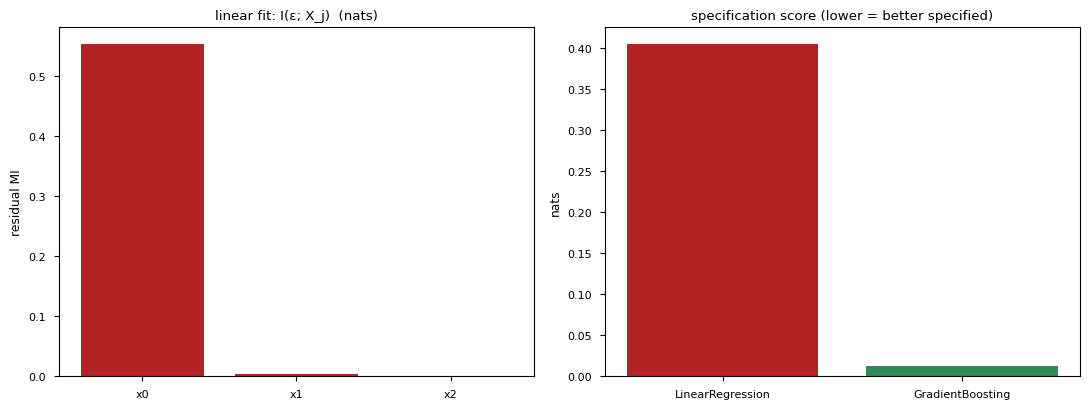

In [4]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.2))
ax0.bar(["x0", "x1", "x2"], lin.residual_mi_, color="firebrick")
ax0.set_title("linear fit: I(ε; X_j)  (nats)")
ax0.set_ylabel("residual MI")

models = ["LinearRegression", "GradientBoosting"]
scores = [lin.specification_score_, gbm.specification_score_]
ax1.bar(models, scores, color=["firebrick", "seagreen"])
ax1.set_title("specification score (lower = better specified)")
ax1.set_ylabel("nats")
plt.tight_layout()
plt.show()

In [5]:
print(f"linear specification score: {lin.specification_score_:.3f}")
print(f"GBM specification score:    {gbm.specification_score_:.3f}")
print(f"linear worst feature: x{int(np.argmax(lin.residual_mi_))}")

linear specification score: 0.405
GBM specification score:    0.013
linear worst feature: x0


## Takeaways

- The diagnostic **names the feature** (`x0`) whose missed term inflates
  the residual, and the composite score ranks the well-specified GBM
  far below the misspecified linear fit — a model-selection signal, not
  an absolute threshold.
- Two estimator-level bias fixes make this work: **quadratic block
  augmentation** (the rotation-based MI estimator is otherwise blind to
  even-symmetric dependence — exactly a missed `x²` term) and a
  **bias-matched** negentropy baseline. Both are documented in the
  class.
- For flexible models whose in-sample residuals look optimistically
  Gaussian, pass `cv=5` to diagnose **out-of-fold** residuals instead.